## **Lexical Bridge Photo Mission - Data Collection**

### **Purpose**

The purpose of this notebook is to collect and prepare an image dataset for the Lexical Bridge photo mission feature. Images are downloaded from Open Images V7 using the FiftyOne dataset zoo, cropped using object bounding boxes, mapped into ten selected classes and three broader categories, then split into train, validation, and test sets using source-image identifiers to reduce data leakage. The final output is a zipped dataset file that can be reused for EDA and CNN model training.

### **Structure**
1. Install required libraries
2. Configure target classes, category mappings, and dataset paths
3. Download selected classes from Open Images V7
4. Extract bounding box crops from downloaded images
5. Limit each class to a target number of cropped images
6. Clean temporary files
7. Split dataset into train, validation, and test sets using source image identifiers
8. Visualize sample images
9. Export dataset as a ZIP file

## 1. Install Required Libraries

In [ ]:
!pip install -q fiftyone pillow tqdm

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.7/17.7 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.5/323.5 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.9/112.9 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.6/101.6 kB 12.3 MB/s eta 

## 2. Dataset Configuration

In [ ]:
import os
import random
import shutil
from pathlib import Path
from collections import defaultdict
from PIL import Image
from tqdm import tqdm

SEED = 42
random.seed(SEED)
# Require many samples for training own CNN model
TARGET_PER_CLASS = 1000
MAX_DOWNLOAD_SAMPLES = 30000
MIN_CROP_SIZE = 96
MAX_CROPS_PER_IMAGE_CLASS = 1

# Map Open Images labels to the class names used in this project
FO_LABEL_MAP = {
    'Cat': 'cat',
    'Horse':  'horse',
    'Bird':  'bird',
    'Fish':     'fish',
    'Book':     'books',
    'Chair':    'chair',
    'Umbrella': 'umbrella',
    'Airplane': 'airplane',
    'Bicycle':  'bicycle',
    'Boat':     'boat',
}
FO_CLASSES = list(FO_LABEL_MAP.keys())

# Map detailed classes into broader game categories (4 / 3 / 3)
CATEGORY_MAP = {
    'cat':      'animals', 'horse': 'animals', 'bird': 'animals', 'fish': 'animals',
    'books':    'daily_life', 'chair': 'daily_life', 'umbrella': 'daily_life',
    'airplane': 'vehicles',   'bicycle': 'vehicles', 'boat':    'vehicles',
}

# Temporary working directories in the Colab environment
RAW_DIR     = Path('/content/open_images_raw')
CROP_DIR    = Path('/content/crops')
DATASET_DIR = Path('/content/dataset')

print(f'Classes ({len(CATEGORY_MAP)}): {list(CATEGORY_MAP.keys())}')
print(f'Categories: {sorted(set(CATEGORY_MAP.values()))}')
print(f'Target images per class: {TARGET_PER_CLASS}')
print(f'Maximum download samples: {MAX_DOWNLOAD_SAMPLES}')

Classes (10): ['cat', 'horse', 'bird', 'fish', 'books', 'chair', 'umbrella', 'airplane', 'bicycle', 'boat']
Categories: ['animals', 'daily_life', 'vehicles']
Target images per class: 1000
Maximum download samples: 30000


## 3. Download Open Images V7 Dataset

In [ ]:
import fiftyone as fo
import fiftyone.zoo as foz

# Remove existing Open Images datasets to avoid conflicts
for ds_name in fo.list_datasets():
    if 'open-images' in ds_name:
        fo.delete_dataset(ds_name)
        print(f'Deleted: {ds_name}')

print(f'Downloading Open Images V7 for: {FO_CLASSES}')

# Download selected classes from Open Images V7 using the FiftyOne dataset zoo
fo_dataset = foz.load_zoo_dataset(
    'open-images-v7',
    split='train',
    label_types=['detections'],
    classes=FO_CLASSES,
    max_samples=MAX_DOWNLOAD_SAMPLES,
    shuffle=True,
    seed=SEED,
    only_matching=True
)

print(f'\nDownloaded samples: {len(fo_dataset)}')

/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


INFO:fiftyone.zoo.datasets:Downloading split 'train' to '/root/fiftyone/open-images-v7/train' if necessary


INFO:fiftyone.utils.openimages:Downloading 'https://storage.googleapis.com/openimages/2018_04/train/train-images-boxable-with-rotation.csv' to '/root/fiftyone/open-images-v7/train/metadata/image_ids.csv'


 100% |██████|    4.8Gb/4.8Gb [9.0s elapsed, 0s remaining, 714.4Mb/s]      


INFO:eta.core.utils: 100% |██████|    4.8Gb/4.8Gb [9.0s elapsed, 0s remaining, 714.4Mb/s]      


...

 100% |█████████████| 30000/30000 [2.0m elapsed, 0s remaining, 262.4 samples/s]      


INFO:eta.core.utils: 100% |█████████████| 30000/30000 [2.0m elapsed, 0s remaining, 262.4 samples/s]      


Dataset 'open-images-v7-train-30000' created


INFO:fiftyone.zoo.datasets:Dataset 'open-images-v7-train-30000' created



Downloaded samples: 30000


## 4. Extract Bounding Box Crops

In [ ]:
# Automatically detect the field that contains object detection labels
def get_detection_field(dataset):
    sample = dataset.first()
    for field_name in sample.field_names:
        value = sample.get_field(field_name)
        if isinstance(value, fo.core.labels.Detections):
            return field_name
    raise ValueError('No detection field found')
DETECTION_FIELD = get_detection_field(fo_dataset)
print(f'Detection field: {DETECTION_FIELD}')

# Reset the crop directory before saving new cropped images
if CROP_DIR.exists():
    shutil.rmtree(CROP_DIR)
for cls in FO_LABEL_MAP.values():
    (CROP_DIR / cls).mkdir(parents=True, exist_ok=True)
counts = defaultdict(int)
all_targets = set(FO_LABEL_MAP.values())
skipped = defaultdict(int)  # Track filter reasons for diagnostics

# Iterate through downloaded images and extract object crops
for src_idx, sample in enumerate(tqdm(fo_dataset, desc='Cropping')):
    # Stop when all classes have reached the target number of images
    if all(counts[cls] >= TARGET_PER_CLASS for cls in all_targets):
        break
    try:
        image = Image.open(sample.filepath).convert('RGB')
    except Exception:
        skipped['image_open_failed'] += 1
        continue

    # Safely access the detection field — some samples may have no detections
    det_field = sample[DETECTION_FIELD]
    if det_field is None or det_field.detections is None:
        skipped['no_detections'] += 1
        continue
    iw, ih = image.size
    detections = det_field.detections

    # Per-image, per-class cap to avoid near-duplicate crops from the same scene
    per_image_class_count = defaultdict(int)
    for det in detections:
        label = det.label
        if label not in FO_LABEL_MAP:
            continue
        cls = FO_LABEL_MAP[label]
        # Skip this class if the target count has already been reached
        if counts[cls] >= TARGET_PER_CLASS:
            continue
        # Skip group-of boxes (multiple instances in one box → bad for classification)
        if getattr(det, 'IsGroupOf', False):
            skipped['is_group_of'] += 1
            continue
        # Limit crops per (image, class)
        if per_image_class_count[cls] >= MAX_CROPS_PER_IMAGE_CLASS:
            continue
        # Convert normalized bounding box coordinates into pixel coordinates
        x, y, w, h = det.bounding_box
        left   = max(0,  int(x * iw))
        top    = max(0,  int(y * ih))
        right  = min(iw, int((x + w) * iw))
        bottom = min(ih, int((y + h) * ih))
        cw, ch = right - left, bottom - top

        # Remove crops that are too small for reliable training
        if cw < MIN_CROP_SIZE or ch < MIN_CROP_SIZE:
            skipped['too_small'] += 1
            continue
        # Remove extreme aspect ratios (heavily clipped or sliver boxes)
        ar = max(cw, ch) / max(1, min(cw, ch))
        if ar > 4.0:
            skipped['extreme_aspect_ratio'] += 1
            continue
        try:
            crop = image.crop((left, top, right, bottom))
            # Filename encodes source image idx → enables image-level split
            fname = f'{cls}_src{src_idx:06d}_{counts[cls]:04d}.jpg'
            crop.save(CROP_DIR / cls / fname, quality=95)
            counts[cls] += 1
            per_image_class_count[cls] += 1
        except Exception:
            skipped['crop_save_failed'] += 1
            continue

print('\nCrop Summary')
for cls in sorted(all_targets):
    n = counts[cls]
    status = 'Complete' if n >= TARGET_PER_CLASS else 'Incomplete'
    print(f'  [{status:>10}] {cls:<10}: {n}/{TARGET_PER_CLASS}')
print(f'\nTotal cropped images: {sum(counts.values())}')
print(f'\nFilter diagnostics: {dict(skipped)}')

Detection field: ground_truth


Cropping: 100%|██████████| 30000/30000 [06:03<00:00, 82.58it/s]


Crop Summary
  [  Complete] airplane  : 1000/1000
  [  Complete] bicycle   : 1000/1000
  [  Complete] bird      : 1000/1000
  [  Complete] boat      : 1000/1000
  [  Complete] books     : 1000/1000
  [  Complete] cat       : 1000/1000
  [  Complete] chair     : 1000/1000
  [  Complete] fish      : 1000/1000
  [  Complete] horse     : 1000/1000
  [Incomplete] umbrella  : 654/1000

Total cropped images: 9654

Filter diagnostics: {'extreme_aspect_ratio': 233, 'is_group_of': 6375, 'too_small': 7817}


## 5. Class Count Report

In [ ]:
# Count downloaded dataset
class_counts = {cls: len(list((CROP_DIR / cls).glob('*.jpg'))) for cls in all_targets}

print('Final class counts')
print(f'{"class":<10} {"count":>6}')
print('-' * 18)
for cls in sorted(class_counts):
    print(f'{cls:<10} {class_counts[cls]:>6}')
print(f'\nTotal: {sum(class_counts.values())}')

Final class counts
class       count
------------------
airplane     1000
bicycle      1000
bird         1000
boat         1000
books        1000
cat          1000
chair        1000
fish         1000
horse        1000
umbrella      654

Total: 9654


## 6. Clean Temporary Files

In [ ]:
if RAW_DIR.exists():
    shutil.rmtree(RAW_DIR)
    print(f'Deleted: {RAW_DIR}')
# Check remaining disk usage in the Colab environment
!df -h /content

Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   56G   57G  50% /


## 7. Split Dataset by Source Image (Train / Val / Test)

In [ ]:
import re
# Reset the final dataset directory
if DATASET_DIR.exists():
    shutil.rmtree(DATASET_DIR)

# Create train, validation, and test folders for each class
for split in ['train', 'val', 'test']:
    for cls in CATEGORY_MAP:
        (DATASET_DIR / split / cls).mkdir(parents=True, exist_ok=True)

# Extract source image index from filename pattern
SRC_RE = re.compile(r'_src(\d+)_')
def get_source_id(path: Path) -> int:
    m = SRC_RE.search(path.name)
    return int(m.group(1)) if m else -1
split_summary = {}

# Split source images (not crops) per class into 70/15/15
for cls in CATEGORY_MAP:
    files = list((CROP_DIR / cls).glob('*.jpg'))
    # Group crops by their source image id
    by_src = defaultdict(list)
    for f in files:
        by_src[get_source_id(f)].append(f)
    src_ids = list(by_src.keys())
    random.shuffle(src_ids)
    n_src = len(src_ids)
    t1 = int(n_src * 0.70)
    t2 = int(n_src * 0.85)

    train_srcs = src_ids[:t1]
    val_srcs   = src_ids[t1:t2]
    test_srcs  = src_ids[t2:]
    splits = {
        'train': [f for sid in train_srcs for f in by_src[sid]],
        'val':   [f for sid in val_srcs   for f in by_src[sid]],
        'test':  [f for sid in test_srcs  for f in by_src[sid]],
    }
    split_summary[cls] = {k: len(v) for k, v in splits.items()}

    # Copy each image into the corresponding split folder
    for split_name, file_list in splits.items():
        for f in file_list:
            shutil.copy(f, DATASET_DIR / split_name / cls / f.name)

print('Split Summary (split by source image to prevent leakage)')
print(f'{"class":<12} {"train":>6} {"val":>6} {"test":>6} {"total":>6}')
print('-' * 45)
for cls, s in split_summary.items():
    total = s['train'] + s['val'] + s['test']
    print(f'{cls:<12} {s["train"]:>6} {s["val"]:>6} {s["test"]:>6} {total:>6}')

Split Summary (split by source image to prevent leakage)
class         train    val   test  total
---------------------------------------------
cat             700    150    150   1000
horse           700    150    150   1000
bird            700    150    150   1000
fish            700    150    150   1000
books           700    150    150   1000
chair           700    150    150   1000
umbrella        457     98     99    654
airplane        700    150    150   1000
bicycle         700    150    150   1000
boat            700    150    150   1000


## 8. Visualize Sample Images

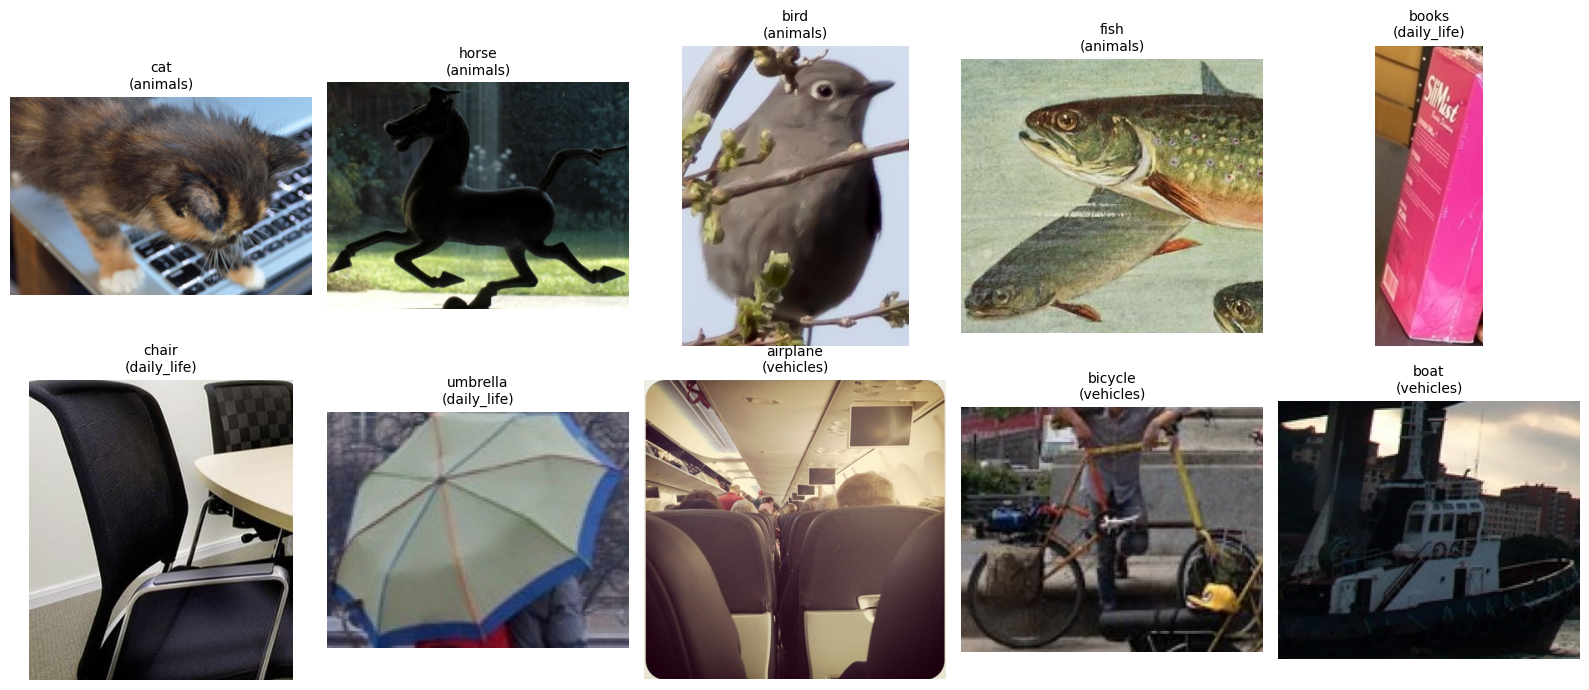

In [ ]:
import matplotlib.pyplot as plt

# 10 classes → 2x5 grid
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for ax, cls in zip(axes.flatten(), CATEGORY_MAP.keys()):
    files = list((DATASET_DIR / 'train' / cls).glob('*.jpg'))
    if files:
        img = Image.open(random.choice(files)).convert('RGB')
        ax.imshow(img)
    # Show the class name and its broader category
    ax.set_title(f'{cls}\n({CATEGORY_MAP[cls]})', fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 9. Export Dataset as ZIP File and Download

In [ ]:
# Clean FiftyOne cache only now that everything is exported
FO_CACHE = Path(os.path.expanduser('~/.fiftyone'))
if FO_CACHE.exists():
    shutil.rmtree(FO_CACHE)
    print(f'Deleted: {FO_CACHE}')

from google.colab import files
zip_path = '/content/LB2_dataset'
shutil.make_archive(zip_path, 'zip', str(DATASET_DIR))

size_mb = Path(f'{zip_path}.zip').stat().st_size / (1024 * 1024)
print(f'ZIP file created: {zip_path}.zip ({size_mb:.1f} MB)')
files.download('/content/LB2_dataset.zip')

Deleted: /root/.fiftyone
ZIP file created: /content/LB2_dataset.zip (772.8 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>